/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

  0%|          | 0/156 [00:00<?, ?it/s]

  0%|          | 0/156 [00:00<?, ?it/s]

  0%|          | 0/156 [00:00<?, ?it/s]

ELECTRA testset size: 624
ELECTRA:
Confusion Matrix:
[[0.91062802 0.08937198]
 [0.48095238 0.51904762]]

Accuracy: 0.7788461538461539
Precision: 0.7887029288702929
Recall: 0.9106280193236715
F1 Score: 0.8452914798206278


(0.7788461538461539,
 0.7887029288702929,
 0.9106280193236715,
 0.8452914798206278)

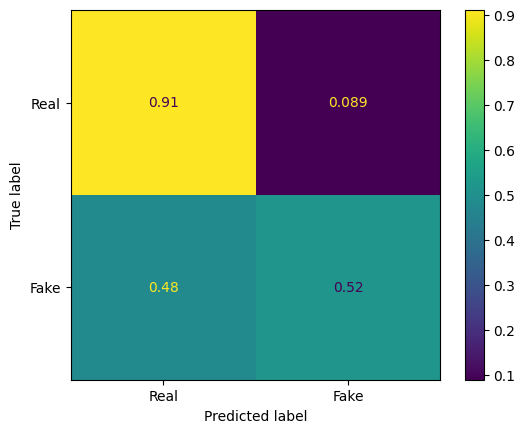

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
from transformers import ElectraForSequenceClassification, ElectraTokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score
from tqdm.notebook import tqdm

class FakeNewsDataset(Dataset):
    def __init__(self, mode, tokenizer, path):
        assert mode in ['train', 'test']
        self.mode = mode
        self.df = pd.read_csv(path + mode + '.tsv', sep='\t').fillna('')
        self.len = len(self.df)
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        statement, label = self.df.iloc[idx, :].values
        label_tensor = torch.tensor(label)

        word_pieces = ['[CLS]']
        statement = self.tokenizer.tokenize(statement)
        word_pieces += statement + ['[SEP]']
        len_st = len(word_pieces)

        ids = self.tokenizer.convert_tokens_to_ids(word_pieces)
        tokens_tensor = torch.tensor(ids)

        segments_tensor = torch.tensor([0] * len_st, dtype=torch.long)

        return (tokens_tensor, segments_tensor, label_tensor)

    def __len__(self):
        return self.len

def create_mini_batch(samples):
    tokens_tensors = [s[0] for s in samples]
    segments_tensors = [s[1] for s in samples]

    if samples[0][2] is not None:
        label_ids = torch.stack([s[2] for s in samples])
    else:
        label_ids = None

    # zero padding
    tokens_tensors = pad_sequence(tokens_tensors, batch_first=True)
    segments_tensors = pad_sequence(segments_tensors, batch_first=True)

    masks_tensors = torch.zeros(tokens_tensors.shape, dtype=torch.long)
    masks_tensors = masks_tensors.masked_fill(tokens_tensors != 0, 1)

    return tokens_tensors, segments_tensors, masks_tensors, label_ids

BATCH_SIZE = 16
MODEL_NAME = 'google/electra-small-discriminator'
tokenizer = ElectraTokenizer.from_pretrained(MODEL_NAME)

NUM_LABELS = 2
model = ElectraForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS)

# Move model to device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model.to(device)

def evaluate(testloader):
    true = []
    predictions = []
    with torch.no_grad():
        model.eval()
        for data in testloader:
            if next(model.parameters()).is_cuda:
                data = [t.to(device) for t in data if t is not None]

            tokens_tensors, segments_tensors, masks_tensors = data[:3]
            test_outputs = model(input_ids=tokens_tensors,
                               attention_mask=masks_tensors)

            logits = test_outputs.logits
            _, pred = torch.max(logits.data, 1)

            labels = data[3]
            true.extend(labels.cpu().tolist())
            predictions.extend(pred.cpu().tolist())

    cm = confusion_matrix(true, predictions, labels=[1, 0], normalize='true')
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot()

    accuracy = accuracy_score(true, predictions)
    precision = precision_score(true, predictions)
    recall = recall_score(true, predictions)
    f1 = f1_score(true, predictions)

    print('\nAccuracy:', accuracy)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)

    return accuracy, precision, recall, f1

# Your training and fine-tuning code remains unchanged
trainset = FakeNewsDataset('train', tokenizer=tokenizer, path='./')
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)
model.to(device)

model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    train_loss = 0.0
    train_acc = 0.0

    loop = tqdm(trainloader)
    for batch_idx, data in enumerate(loop):
        tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]

        optimizer.zero_grad()

        outputs = model(input_ids=tokens_tensors,
                      attention_mask=masks_tensors,
                      labels=labels)

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        logits = outputs.logits
        _, pred = torch.max(logits.data, 1)
        train_acc = accuracy_score(pred.cpu().tolist(), labels.cpu().tolist())

        train_loss += loss.item()

        loop.set_description(f'Epoch [{epoch + 1}/{NUM_EPOCHS}]')
        loop.set_postfix(acc=train_acc, loss=train_loss/(batch_idx+1))

# Example usage:
testset_electra = FakeNewsDataset('test', tokenizer=tokenizer, path='./')
print('ELECTRA testset size:', testset_electra.__len__())
testloader_electra = DataLoader(testset_electra, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)

print('ELECTRA:')
print('Confusion Matrix:')
evaluate(testloader_electra)
